# Wafer Anomaly Detection — PatchCore + ViT-B/16 (WM-811K)

Backbone: **ViT-B/16** (pretrained on ImageNet-21k via `timm`)  
Hardware target: **RTX 4060 8 GB VRAM, 32 GB RAM**

## Why the previous version crashed (and how this one fixes it)

The crash came from `build_tensor()` — it pre-converted every wafer map to a
float32 tensor and stacked them all in RAM **before** any training started.

```
150k images × 224 × 224 × 3 channels × 4 bytes = ~30 GB   ← OOM on 32 GB machine
```

This notebook uses a **lazy `WaferDataset`** instead.  
Wafer maps stay as compact numpy arrays inside the DataFrame (~few KB each).  
The DataLoader converts **one batch at a time** only when needed.

| Approach | RAM for 150k images | Peak during run |
|---|---|---|
| Pre-built tensors (old) | ~30 GB | ~30 GB + model |
| Lazy `WaferDataset` (this) | ~2–4 GB (raw maps) | ~4–6 GB total |

## Pipeline
1. Load WM-811K, clean, split → DataFrames only (no tensors)
2. `WaferDataset` converts maps on-the-fly per batch
3. ViT-B/16 extracts patch token embeddings (block 6 of 12)
4. Build PatchCore memory bank from train-normal tokens
5. Tune threshold on tune-normal only (no defect leakage)
6. Final evaluation on held-out test split

In [1]:
# -- 0. Install dependencies if needed -----------------------------------------
import importlib, subprocess, sys
for pkg in ['timm', 'tqdm']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('timm + tqdm ready')

timm + tqdm ready


In [2]:
# -- 1. Imports ----------------------------------------------------------------
import os, gc, random, warnings, json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from tqdm.auto import tqdm
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Device:', DEVICE)
if USE_CUDA:
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f} GB')

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "wafer_defect").exists():
        PROJECT_ROOT = candidate
        break
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.evaluation import export_reference_umap_bundle
from wafer_defect.data.legacy_pickle import read_legacy_pickle


Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU  VRAM: 8.6 GB


In [3]:
# -- 2. Configuration ----------------------------------------------------------
DATA_PATH  = PROJECT_ROOT / 'data' / 'raw' / 'LSWMD.pkl'
IMAGE_SIZE = 224

# Report-compatible train/validation setup shared with the x224 experiments.
TRAIN_NORMAL_N = 40_000
TUNE_NORMAL_N  =  5_000

# Two evaluation regimes:
# - main benchmark: 5k normal + 250 defect
# - secondary holdout: 70k normal + 3.5k defect
SECONDARY_HOLDOUT_MODE = False
MAIN_TEST_NORMAL_N     =  5_000
MAIN_TEST_DEFECT_N     =    250
HOLDOUT_TEST_NORMAL_N  = 70_000
HOLDOUT_TEST_DEFECT_N  =  3_500

TEST_NORMAL_N = HOLDOUT_TEST_NORMAL_N if SECONDARY_HOLDOUT_MODE else MAIN_TEST_NORMAL_N
TEST_DEFECT_N = HOLDOUT_TEST_DEFECT_N if SECONDARY_HOLDOUT_MODE else MAIN_TEST_DEFECT_N
EVAL_MODE_NAME = 'holdout70k_3p5k' if SECONDARY_HOLDOUT_MODE else 'main_5pct'

# ViT settings
# Block 6 of 12 is the sweet spot: mid-level structural + semantic features.
# Change to 3-5 for faster/lighter, 8-9 for more semantic richness.
VIT_FEATURE_BLOCK = 6
PATCH_EMBED_DIM   = 128    # project 768-d tokens -> 128-d to save VRAM

# Memory bank
# 40k images x 196 tokens = 7.8M patches; cap at 400k to stay lightweight.
MEMORY_BANK_MAX_PATCHES = 400_000

# Scoring
SCORE_CHUNK      = 512    # reduce to 256 if CUDA OOM during scoring
PATCHCORE_NN_K   = 3
TOPK_PATCH_RATIO = 0.1    # 196 tokens x 0.1 ~= top-20 per image

# DataLoader
# NUM_WORKERS=4 uses multiprocessing - zero overhead for RAM since each
# worker only holds one batch of raw maps at a time.
# On Windows: set NUM_WORKERS=0 if you hit pickle errors.
BATCH_SIZE  = 128
NUM_WORKERS = 0

# Threshold policy
DEFAULT_THRESHOLD_QUANTILE = 0.95
MAX_UMAP_TRAIN_REFERENCE = 5000
MAX_UMAP_VAL_NORMAL = 5000
MAX_UMAP_TEST_NORMAL = 8000 if SECONDARY_HOLDOUT_MODE else 5000
MAX_UMAP_TEST_ANOMALY = 3500 if SECONDARY_HOLDOUT_MODE else 250
THRESHOLD_PERCENTILE_MIN   = 90
THRESHOLD_PERCENTILE_MAX   = 99.9
THRESHOLD_PERCENTILE_STEPS = 100
THRESHOLD_GRID_STEPS       = 300

# Outputs
VARIANT_NAME = 'vit_b16_one_layer_patchcore_x224_holdout70k' if SECONDARY_HOLDOUT_MODE else 'vit_b16_one_layer_patchcore_x224'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts' / 'x224' / 'patchcore_vit_b16_5pct'
ARTIFACT_DIR = ARTIFACT_ROOT / EVAL_MODE_NAME
MODEL_EXPORT_PATH          = ARTIFACT_DIR / 'patchcore_vit_b16_model.pt'
METRICS_EXPORT_PATH        = ARTIFACT_DIR / 'evaluation_metrics.json'
SUMMARY_EXPORT_PATH        = ARTIFACT_DIR / 'summary.json'
TUNE_DIST_PLOT_PATH        = ARTIFACT_DIR / 'tune_score_dist.png'
TEST_EVAL_PLOT_PATH        = ARTIFACT_DIR / 'test_eval.png'
THRESHOLD_SWEEP_PLOT_PATH  = ARTIFACT_DIR / 'threshold_sweep_metrics.png'
THRESHOLD_SWEEP_CSV_PATH   = ARTIFACT_DIR / 'threshold_sweep.csv'
UMAP_PNG_PATH              = ARTIFACT_DIR / 'umap_test_embeddings.png'
UMAP_CSV_PATH              = ARTIFACT_DIR / 'umap_test_embeddings.csv'
VAL_SCORES_CSV_PATH        = ARTIFACT_DIR / 'val_scores.csv'
TEST_SCORES_CSV_PATH       = ARTIFACT_DIR / 'test_scores.csv'
DEFECT_BREAKDOWN_CSV_PATH  = ARTIFACT_DIR / 'defect_breakdown.csv'
CONFIG_EXPORT_PATH         = ARTIFACT_DIR / 'config.json'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = dict(
    run=dict(
        variant_name=VARIANT_NAME,
        output_dir=str(ARTIFACT_DIR.relative_to(PROJECT_ROOT)),
        seed=SEED,
        evaluation_mode=EVAL_MODE_NAME,
        secondary_holdout_mode=SECONDARY_HOLDOUT_MODE,
    ),
    data=dict(
        raw_pickle=str(DATA_PATH.relative_to(PROJECT_ROOT)),
        image_size=IMAGE_SIZE,
        train_normal_count=TRAIN_NORMAL_N,
        val_normal_count=TUNE_NORMAL_N,
        main_test_normal_count=MAIN_TEST_NORMAL_N,
        main_test_defect_count=MAIN_TEST_DEFECT_N,
        holdout_test_normal_count=HOLDOUT_TEST_NORMAL_N,
        holdout_test_defect_count=HOLDOUT_TEST_DEFECT_N,
        selected_test_normal_count=TEST_NORMAL_N,
        selected_test_defect_count=TEST_DEFECT_N,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    ),
    model=dict(
        backbone='vit_base_patch16_224.augreg_in21k_ft_in1k',
        vit_feature_block=VIT_FEATURE_BLOCK,
        patch_embed_dim=PATCH_EMBED_DIM,
        memory_bank_max_patches=MEMORY_BANK_MAX_PATCHES,
        score_chunk=SCORE_CHUNK,
        patchcore_nn_k=PATCHCORE_NN_K,
        topk_patch_ratio=TOPK_PATCH_RATIO,
    ),
    scoring=dict(threshold_quantile=DEFAULT_THRESHOLD_QUANTILE),
    umap=dict(
        fit='train_normal_only',
        threshold_source='val_normal_only',
        metric='cosine',
        metric_note='ViT-specific choice; CNN PatchCore report runs use euclidean.',
        pca_components=32,
        n_neighbors=15,
        min_dist=0.1,
        knn_k=15,
        max_train_reference=MAX_UMAP_TRAIN_REFERENCE,
        max_val_normal=MAX_UMAP_VAL_NORMAL,
        max_test_normal=MAX_UMAP_TEST_NORMAL,
        max_test_anomaly=MAX_UMAP_TEST_ANOMALY,
    ),
)
CONFIG_EXPORT_PATH.write_text(json.dumps(CONFIG, indent=2), encoding='utf-8')

print(f'Evaluation mode={EVAL_MODE_NAME}')
print(f'ViT block={VIT_FEATURE_BLOCK}  embed_dim={PATCH_EMBED_DIM}')
print(f'Bank cap={MEMORY_BANK_MAX_PATCHES:,}  batch={BATCH_SIZE}  workers={NUM_WORKERS}')
print(f'Default threshold quantile={DEFAULT_THRESHOLD_QUANTILE:.0%}')
print(f'Artifacts -> {ARTIFACT_DIR}')


Evaluation mode=main_5pct
ViT block=6  embed_dim=128
Bank cap=400,000  batch=128  workers=0
Default threshold quantile=95%
Artifacts -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct


In [4]:
# ── 3. Load & clean dataset ───────────────────────────────────────────────────
# Only DataFrames are created here — NO tensors, NO float32 copies.
# Raw wafer maps stay as object-dtype numpy arrays in the DataFrame.

df = read_legacy_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(v):
    if v is None: return 'unknown'
    if isinstance(v, float) and np.isnan(v): return 'unknown'
    if isinstance(v, (list, tuple, np.ndarray)):
        a = np.array(v).reshape(-1)
        return 'unknown' if len(a) == 0 else str(a[0])
    return str(v)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).str.strip()

invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print(f'Labeled: {len(df):,}   Normal: {len(normal_df):,}   Defect: {len(defect_df):,}')
print('\nDefect breakdown:')
print(defect_df['failure_label'].value_counts())

Raw shape: (811457, 6)
Labeled: 172,950   Normal: 147,431   Defect: 25,519

Defect breakdown:
failure_label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [5]:
# 4. Split 
req_n = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
req_d = TEST_DEFECT_N

if len(normal_df) < req_n:
    raise ValueError(f'Need {req_n:,} normals, have {len(normal_df):,}')
if len(defect_df) < req_d:
    raise ValueError(f'Need {req_d:,} defects, have {len(defect_df):,}')

rng = np.random.default_rng(SEED)
ns = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
ds = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

a = TRAIN_NORMAL_N
b = a + TUNE_NORMAL_N
c = b + TEST_NORMAL_N

train_normal_df = ns.iloc[0:a].copy()
tune_normal_df  = ns.iloc[a:b].copy()
test_normal_df  = ns.iloc[b:c].copy()
test_defect_df  = ds.iloc[0:TEST_DEFECT_N].copy()

# Free the large unsplit dataframes ? keep only the slices
del df, normal_df, defect_df, ns, ds
gc.collect()

print(f'Split mode    : {EVAL_MODE_NAME}')
print(f'Train normal  : {len(train_normal_df):>7,}')
print(f'Tune  normal  : {len(tune_normal_df):>7,}')
print(f'Test  normal  : {len(test_normal_df):>7,}')
print(f'Test  defect  : {len(test_defect_df):>7,}')


Split mode    : main_5pct
Train normal  :  40,000
Tune  normal  :   5,000
Test  normal  :   5,000
Test  defect  :     250


In [6]:
# ── 5. Lazy WaferDataset ──────────────────────────────────────────────────────
#
# KEY RAM FIX: no tensor is created until __getitem__ is called for a single
# sample. The DataLoader batches these calls across NUM_WORKERS processes,
# so at most BATCH_SIZE tensors exist in memory at once.
#
# Raw map storage: 1 wafer map ≈ 26×26 int8 ≈ 700 bytes
# vs tensor:       1 wafer map ≈ 224×224×3 float32 ≈ 602 KB
# Ratio: ~860× more compact in the DataFrame.

class WaferDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, size: int = 224):
        self.maps   = frame['waferMap'].values   # numpy object array of 2-D arrays
        self.labels = frame['is_anomaly'].values.astype(np.int64)
        self.size   = size

    def __len__(self):
        return len(self.maps)

    def __getitem__(self, idx):
        arr = np.clip(np.array(self.maps[idx], dtype=np.int64), 0, 2)
        x   = torch.tensor(arr, dtype=torch.long)
        x   = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()  # [3, H, W]
        x   = F.interpolate(
                  x.unsqueeze(0),
                  size=(self.size, self.size),
                  mode='nearest'
              ).squeeze(0)                                            # [3, 224, 224]
        return x, int(self.labels[idx])


loader_kw = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_CUDA,
    persistent_workers=(NUM_WORKERS > 0),
)

train_loader       = DataLoader(WaferDataset(train_normal_df, IMAGE_SIZE), **loader_kw)
tune_normal_loader = DataLoader(WaferDataset(tune_normal_df,  IMAGE_SIZE), **loader_kw)
test_normal_loader = DataLoader(WaferDataset(test_normal_df,  IMAGE_SIZE), **loader_kw)
test_defect_loader = DataLoader(WaferDataset(test_defect_df,  IMAGE_SIZE), **loader_kw)

for name, ldr in [('train_normal', train_loader), ('tune_normal', tune_normal_loader),
                  ('test_normal', test_normal_loader), ('test_defect', test_defect_loader)]:
    print(f'{name:<14}: {len(ldr):>4} batches')

# Smoke-test one batch
xb, yb = next(iter(train_loader))
print(f'\nBatch shape: {tuple(xb.shape)}  dtype={xb.dtype}  sample labels={yb[:4].tolist()}')

train_normal  :  313 batches
tune_normal   :   40 batches
test_normal   :   40 batches
test_defect   :    2 batches

Batch shape: (128, 3, 224, 224)  dtype=torch.float32  sample labels=[0, 0, 0, 0]


In [7]:
# ── 6. ViT-B/16 feature extractor ────────────────────────────────────────────
# Forward hook on block[VIT_FEATURE_BLOCK] captures [B, 197, 768] token output.
# We drop the CLS token → [B, 196, 768] spatial patch tokens.
# Projected to [B, 196, PATCH_EMBED_DIM] for memory efficiency.

class ViTPatchExtractor(nn.Module):
    def __init__(self, block_idx: int = VIT_FEATURE_BLOCK,
                 proj_dim: int = PATCH_EMBED_DIM):
        super().__init__()
        self.vit = timm.create_model(
            'vit_base_patch16_224.augreg_in21k_ft_in1k',
            pretrained=True,
            num_classes=0,
        )
        self._feat = None
        self.vit.blocks[block_idx].register_forward_hook(
            lambda m, i, o: setattr(self, '_feat', o)
        )
        self.proj = nn.Linear(768, proj_dim, bias=False)

    def forward(self, x):
        self.vit(x)                    # hook fires mid-pass
        return self._feat[:, 1:, :]    # drop CLS → [B, 196, 768]


extractor = ViTPatchExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

# Smoke-test
with torch.inference_mode():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    out   = extractor(dummy)
    proj  = extractor.proj(out)
print(f'ViT block-{VIT_FEATURE_BLOCK} output : {tuple(out.shape)}')   # [2, 196, 768]
print(f'After projection         : {tuple(proj.shape)}')              # [2, 196, 128]

ViT block-6 output : (2, 196, 768)
After projection         : (2, 196, 128)


In [8]:
# -- 7. Build PatchCore memory bank --------------------------------------------
# Rebuild the ViT extractor if this cell is run in a fresh/restarted kernel
# without rerunning cell 8 first.
if 'extractor' not in globals():
    print('ViT extractor not found in kernel; rebuilding from current config...')
    extractor = ViTPatchExtractor().to(DEVICE).eval()
    for p in extractor.parameters():
        p.requires_grad = False

# 60k images x 196 tokens = 11.7M patches -> subsample to MEMORY_BANK_MAX_PATCHES.
# Sampled tensors stay on GPU; no CPU round-trips.

def extract_embeddings(xb: torch.Tensor) -> torch.Tensor:
    """L2-normalised embeddings: [B*196, proj_dim] on GPU."""
    with torch.inference_mode():
        with torch.autocast('cuda', torch.float16, enabled=USE_CUDA):
            feat = extractor(xb)          # [B, 196, 768]
            emb  = extractor.proj(feat)   # [B, 196, proj_dim]
        emb = emb.float().reshape(-1, emb.shape[-1])
        emb = F.normalize(emb, p=2, dim=1)
    return emb


sampled, total_seen, sample_ratio = [], 0, None

print('Building memory bank...')
bank_iter = tqdm(
    enumerate(train_loader),
    total=len(train_loader),
    desc='Bank build',
    unit='batch',
)
for step, (xb, _) in bank_iter:
    xb  = xb.to(DEVICE)
    emb = extract_embeddings(xb)
    total_seen += len(emb)

    if sample_ratio is None:
        tokens_per_img  = len(emb) // len(xb)
        estimated_total = tokens_per_img * len(train_normal_df)
        sample_ratio    = min(1.0, MEMORY_BANK_MAX_PATCHES / estimated_total)
        print(f'  Tokens/image : {tokens_per_img}')
        print(f'  Est. total   : {estimated_total:,}')
        print(f'  Sample ratio : {sample_ratio:.5f}')

    if sample_ratio < 1.0:
        k   = max(1, int(round(len(emb) * sample_ratio)))
        idx = torch.randperm(len(emb), device=DEVICE)[:k]
        emb = emb[idx]

    sampled.append(emb)

    if (step + 1) % 20 == 0 or (step + 1) == len(train_loader):
        n = sum(len(e) for e in sampled)
        bank_iter.set_postfix(bank_tokens=f'{n:,}')

memory_bank = torch.cat(sampled, dim=0)
del sampled; gc.collect()

if len(memory_bank) > MEMORY_BANK_MAX_PATCHES:
    idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX_PATCHES]
    memory_bank = memory_bank[idx]

memory_bank   = F.normalize(memory_bank, p=2, dim=1).contiguous()
memory_bank_t = memory_bank.t().contiguous()

mb_mb = memory_bank.element_size() * memory_bank.numel() / 1e6
print(f'Final bank : {len(memory_bank):,} x {memory_bank.shape[1]}-d  ({mb_mb:.1f} MB VRAM)')

Building memory bank...


Bank build:   0%|          | 0/313 [00:00<?, ?batch/s]

  Tokens/image : 196
  Est. total   : 7,840,000
  Sample ratio : 0.05102
Final bank : 400,000 x 128-d  (204.8 MB VRAM)


In [9]:
# -- 8. PatchCore scoring -------------------------------------------------------

def min_dist_to_bank(patches, bank_t, chunk=512, k=3):
    out = []
    for i in range(0, len(patches), chunk):
        p    = patches[i:i+chunk]
        sim  = p @ bank_t
        kk   = min(k, sim.shape[1])
        best = sim.topk(kk, dim=1).values
        dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best, min=0.0)).mean(dim=1)
        out.append(dist)
    return torch.cat(out)


def score_loader(loader, bank_t, topk_ratio=0.1, nn_k=3, desc='Scoring'):
    scores = []
    with torch.inference_mode():
        pbar = tqdm(loader, total=len(loader), desc=desc, unit='batch')
        for xb, _ in pbar:
            xb = xb.to(DEVICE)
            with torch.autocast('cuda', torch.float16, enabled=USE_CUDA):
                feat = extractor(xb)
                emb  = extractor.proj(feat)
            emb = emb.float().reshape(-1, emb.shape[-1])
            emb = F.normalize(emb, p=2, dim=1)

            ps   = min_dist_to_bank(emb, bank_t, SCORE_CHUNK, nn_k)
            b    = len(xb)
            ps   = ps.reshape(b, -1)
            topk = max(1, int(round(ps.shape[1] * topk_ratio)))
            topk = min(topk, ps.shape[1])
            s    = ps.topk(topk, dim=1).values.mean(dim=1)
            scores.append(s.cpu())
    return torch.cat(scores).numpy()


kw = dict(topk_ratio=TOPK_PATCH_RATIO, nn_k=PATCHCORE_NN_K)

train_scores       = score_loader(train_loader,       memory_bank_t, desc='Score train-normal', **kw)
tune_normal_scores = score_loader(tune_normal_loader, memory_bank_t, desc='Score tune-normal', **kw)
test_normal_scores = score_loader(test_normal_loader, memory_bank_t, desc='Score test-normal', **kw)
test_defect_scores = score_loader(test_defect_loader, memory_bank_t, desc='Score test-defect', **kw)

# Z-normalise using train-normal statistics
mu  = float(np.mean(train_scores))
std = float(np.std(train_scores) + 1e-8)
def znorm(x): return (x - mu) / std

train_scores_z       = znorm(train_scores)
tune_normal_scores_z = znorm(tune_normal_scores)
test_normal_scores_z = znorm(test_normal_scores)
test_defect_scores_z = znorm(test_defect_scores)

np.savez_compressed(
    ARTIFACT_DIR / 'scores.npz',
    train_scores_z=train_scores_z,
    tune_normal_scores_z=tune_normal_scores_z,
    test_normal_scores_z=test_normal_scores_z,
    test_defect_scores_z=test_defect_scores_z,
    train_mu=np.array(mu), train_std=np.array(std),
)
print(f'\nScores saved. mu={mu:.6f}  sigma={std:.6f}')
pd.DataFrame({'score': tune_normal_scores_z.astype(np.float32), 'is_anomaly': np.zeros(len(tune_normal_scores_z), dtype=np.int64)}).to_csv(VAL_SCORES_CSV_PATH, index=False)
pd.DataFrame({'score': np.concatenate([test_normal_scores_z, test_defect_scores_z]).astype(np.float32), 'is_anomaly': np.concatenate([np.zeros(len(test_normal_scores_z), dtype=np.int64), np.ones(len(test_defect_scores_z), dtype=np.int64)])}).to_csv(TEST_SCORES_CSV_PATH, index=False)
print(f'Saved validation scores CSV: {VAL_SCORES_CSV_PATH}')
print(f'Saved test scores CSV      : {TEST_SCORES_CSV_PATH}')


Score train-normal:   0%|          | 0/313 [00:00<?, ?batch/s]

Score tune-normal:   0%|          | 0/40 [00:00<?, ?batch/s]

Score test-normal:   0%|          | 0/40 [00:00<?, ?batch/s]

Score test-defect:   0%|          | 0/2 [00:00<?, ?batch/s]


Scores saved. mu=0.465908  sigma=0.030877
Saved validation scores CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\val_scores.csv
Saved test scores CSV      : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\test_scores.csv


Evaluation mode: main_5pct
Report-compatible train/val: train=40,000, val=5,000
Selected test pool       : test_normal=5,000, test_defect=250
Threshold selected from tune_normal 95% quantile
z-threshold = 1.6933  raw = 0.518193
Tune_normal range: [-3.552, 6.693]


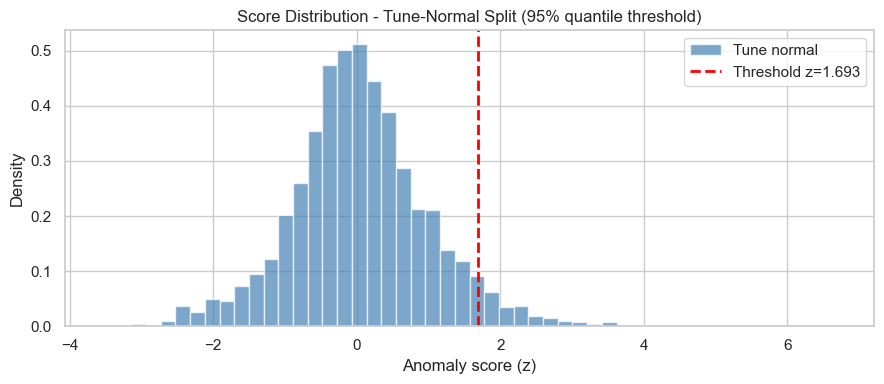

Saved tune-score plot: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\tune_score_dist.png


In [10]:
# -- 9. Threshold selection (tune-normal only, no leakage) ----------------------
# IMPORTANT: threshold is selected from tune_normal scores ONLY.
# No defect split is used during threshold selection.

with np.load(ARTIFACT_DIR / 'scores.npz') as d:
    tune_normal_scores_z = d['tune_normal_scores_z']
    test_normal_scores_z = d['test_normal_scores_z']
    test_defect_scores_z = d['test_defect_scores_z']
    mu  = float(d['train_mu'])
    std = float(d['train_std'])

# Main deployment-style threshold: choose a quantile of tune-normal only.
THRESHOLD_QUANTILE = DEFAULT_THRESHOLD_QUANTILE
threshold_z = float(np.quantile(tune_normal_scores_z, THRESHOLD_QUANTILE))
threshold_raw = mu + threshold_z * std

print(f'Evaluation mode: {EVAL_MODE_NAME}')
print(f'Report-compatible train/val: train={TRAIN_NORMAL_N:,}, val={TUNE_NORMAL_N:,}')
print(f'Selected test pool       : test_normal={TEST_NORMAL_N:,}, test_defect={TEST_DEFECT_N:,}')
print(f'Threshold selected from tune_normal {THRESHOLD_QUANTILE:.0%} quantile')
print(f'z-threshold = {threshold_z:.4f}  raw = {threshold_raw:.6f}')
print(f'Tune_normal range: [{tune_normal_scores_z.min():.3f}, {tune_normal_scores_z.max():.3f}]')

# Score distribution visualization on tune-normal split.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tune_normal_scores_z, bins=50, alpha=0.7, label='Tune normal', color='steelblue', density=True)
ax.axvline(threshold_z, color='red', linewidth=2, linestyle='--', label=f'Threshold z={threshold_z:.3f}')
ax.set_xlabel('Anomaly score (z)')
ax.set_ylabel('Density')
ax.set_title(f'Score Distribution - Tune-Normal Split ({THRESHOLD_QUANTILE:.0%} quantile threshold)')
ax.legend()
plt.tight_layout()
fig.savefig(TUNE_DIST_PLOT_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved tune-score plot: {TUNE_DIST_PLOT_PATH}')


ROC-AUC : 0.9563
Avg Prec: 0.6709
Z-thr   : 1.6933   raw: 0.518193
              precision    recall  f1-score   support

      normal       0.99      0.95      0.97      5000
     anomaly       0.46      0.83      0.60       250

    accuracy                           0.95      5250
   macro avg       0.73      0.89      0.78      5250
weighted avg       0.97      0.95      0.95      5250



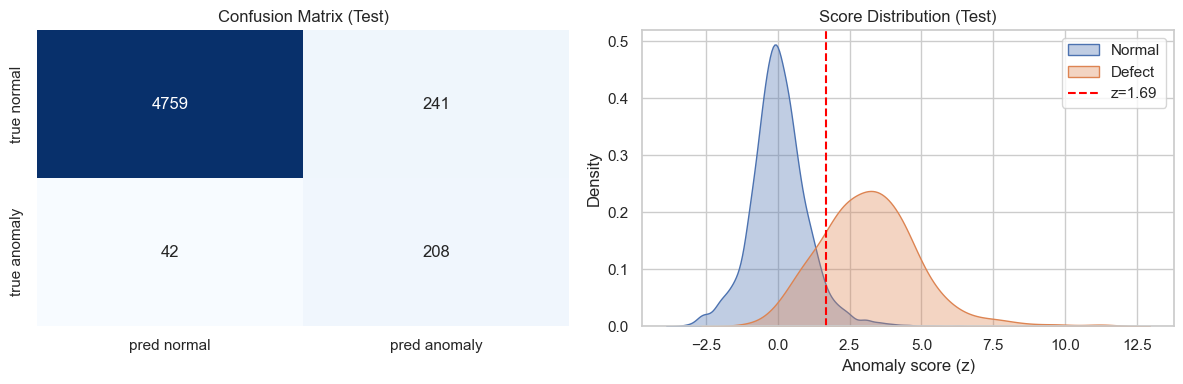

Saved test-eval plot: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\test_eval.png

Per-class defect recall:


,count,detected,recall,mean_score
failure_label,,,,
Center,34,21,0.618,2.294
Edge-Loc,44,31,0.705,2.723
Scratch,11,8,0.727,3.016
Loc,41,34,0.829,3.000
Edge-Ring,102,96,0.941,3.438
Donut,2,2,1.000,5.755
Near-full,3,3,1.000,5.556
Random,13,13,1.000,4.927


Saved defect-breakdown CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\defect_breakdown.csv


In [11]:
# -- 10. Final test evaluation --------------------------------------------------

y_true = np.concatenate([
    np.zeros(len(test_normal_scores_z), dtype=int),
    np.ones(len(test_defect_scores_z), dtype=int),
])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])
y_pred = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
avg_precision = float(average_precision_score(y_true, scores))
report_text = classification_report(y_true, y_pred, target_names=['normal', 'anomaly'])
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=['normal', 'anomaly'],
    output_dict=True,
)

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'Avg Prec: {avg_precision:.4f}')
print(f'Z-thr   : {threshold_z:.4f}   raw: {threshold_raw:.6f}')
print(report_text)

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['pred normal', 'pred anomaly'],
    yticklabels=['true normal', 'true anomaly'],
)
axes[0].set_title('Confusion Matrix (Test)')

sns.kdeplot(test_normal_scores_z, label='Normal', fill=True, alpha=0.35, ax=axes[1])
sns.kdeplot(test_defect_scores_z, label='Defect', fill=True, alpha=0.35, ax=axes[1])
axes[1].axvline(threshold_z, color='red', ls='--', label=f'z={threshold_z:.2f}')
axes[1].set_xlabel('Anomaly score (z)')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution (Test)')
axes[1].legend()
plt.tight_layout()
fig.savefig(TEST_EVAL_PLOT_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved test-eval plot: {TEST_EVAL_PLOT_PATH}')

# Per-class defect recall
per_class_recall_df = test_defect_df.copy()
per_class_recall_df['score'] = test_defect_scores_z
per_class_recall_df['detected'] = (test_defect_scores_z > threshold_z).astype(int)
per_class_recall_df = (
    per_class_recall_df.groupby('failure_label')
    .agg(
        count=('detected', 'count'),
        detected=('detected', 'sum'),
        recall=('detected', 'mean'),
        mean_score=('score', 'mean'),
    )
    .round(3)
    .sort_values('recall')
)
print()
print('Per-class defect recall:')
display(per_class_recall_df)
per_class_recall_df.to_csv(DEFECT_BREAKDOWN_CSV_PATH, index=True)
print(f'Saved defect-breakdown CSV: {DEFECT_BREAKDOWN_CSV_PATH}')


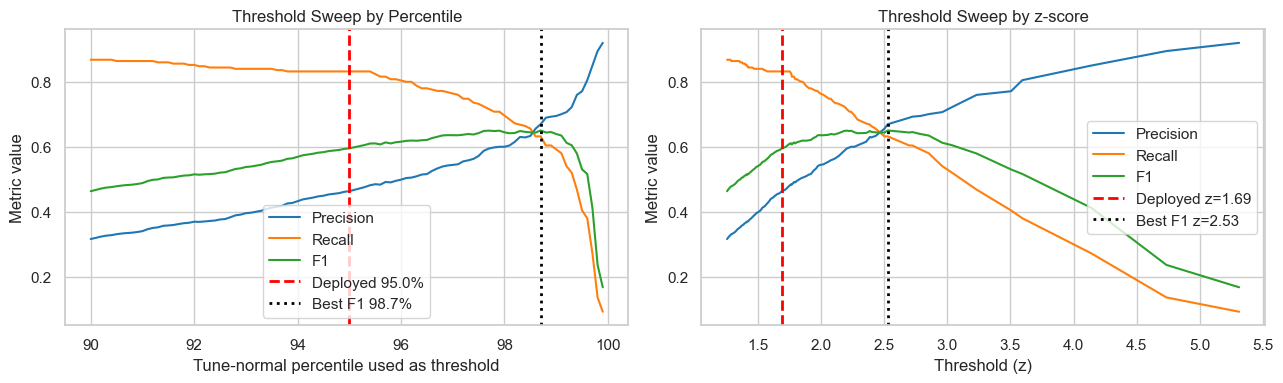

Best sweep point: percentile=98.70, z=2.5289, precision=0.6695, recall=0.6320, f1=0.6502
Saved threshold sweep plot: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\threshold_sweep_metrics.png
Saved threshold sweep CSV : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\threshold_sweep.csv


In [12]:
# -- 10B. Threshold sweep (analysis only) --------------------------------------
# This sweep uses test labels to show threshold sensitivity.
# Keep it for analysis only - not as the main deployment threshold.

percentiles = np.linspace(
    THRESHOLD_PERCENTILE_MIN,
    THRESHOLD_PERCENTILE_MAX,
    THRESHOLD_PERCENTILE_STEPS,
)
rows = []
for pct in percentiles:
    thr = float(np.quantile(tune_normal_scores_z, pct / 100.0))
    pred = (scores > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append(
        dict(
            percentile=float(pct),
            threshold_z=float(thr),
            precision=float(precision),
            recall=float(recall),
            f1=float(f1),
            false_positive_rate=float(fp / (fp + tn)) if (fp + tn) else 0.0,
        )
    )

threshold_sweep_df = pd.DataFrame(rows)
best_idx = threshold_sweep_df['f1'].idxmax()
best_sweep = threshold_sweep_df.loc[best_idx].to_dict()

deployed_pct = THRESHOLD_QUANTILE * 100.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for metric, color in [('precision', 'tab:blue'), ('recall', 'tab:orange'), ('f1', 'tab:green')]:
    axes[0].plot(threshold_sweep_df['percentile'], threshold_sweep_df[metric], label=metric.title(), color=color)
axes[0].axvline(deployed_pct, color='red', linestyle='--', linewidth=2, label=f'Deployed {deployed_pct:.1f}%')
axes[0].axvline(best_sweep['percentile'], color='black', linestyle=':', linewidth=2, label=f'Best F1 {best_sweep["percentile"]:.1f}%')
axes[0].set_xlabel('Tune-normal percentile used as threshold')
axes[0].set_ylabel('Metric value')
axes[0].set_title('Threshold Sweep by Percentile')
axes[0].legend()

for metric, color in [('precision', 'tab:blue'), ('recall', 'tab:orange'), ('f1', 'tab:green')]:
    axes[1].plot(threshold_sweep_df['threshold_z'], threshold_sweep_df[metric], label=metric.title(), color=color)
axes[1].axvline(threshold_z, color='red', linestyle='--', linewidth=2, label=f'Deployed z={threshold_z:.2f}')
axes[1].axvline(best_sweep['threshold_z'], color='black', linestyle=':', linewidth=2, label=f'Best F1 z={best_sweep["threshold_z"]:.2f}')
axes[1].set_xlabel('Threshold (z)')
axes[1].set_ylabel('Metric value')
axes[1].set_title('Threshold Sweep by z-score')
axes[1].legend()

plt.tight_layout()
fig.savefig(THRESHOLD_SWEEP_PLOT_PATH, dpi=160, bbox_inches='tight')
plt.show()

threshold_sweep_df.to_csv(THRESHOLD_SWEEP_CSV_PATH, index=False)
print(
    'Best sweep point: '
    f"percentile={best_sweep['percentile']:.2f}, "
    f"z={best_sweep['threshold_z']:.4f}, "
    f"precision={best_sweep['precision']:.4f}, "
    f"recall={best_sweep['recall']:.4f}, "
    f"f1={best_sweep['f1']:.4f}"
)
print(f'Saved threshold sweep plot: {THRESHOLD_SWEEP_PLOT_PATH}')
print(f'Saved threshold sweep CSV : {THRESHOLD_SWEEP_CSV_PATH}')


In [13]:
# -- 11. UMAP diagnostic (reference-fit train-normal manifold) ------------------
# Rebuild the ViT extractor if this analysis cell is run after a kernel restart
# without rerunning the main model-definition cell.
if 'extractor' not in globals():
    print('ViT extractor not found in kernel; rebuilding from current config...')
    extractor = ViTPatchExtractor().to(DEVICE).eval()
    for p in extractor.parameters():
        p.requires_grad = False

# Geometry-aware alternative thresholding view: fit on train-normal only,
# calibrate UMAP-KNN scores on tune-normal only, then evaluate on test.

import sys, subprocess

try:
    import umap.umap_ as umap
except Exception:
    print('Installing umap-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap.umap_ as umap


def collect_image_embeddings(loader, max_images=None, desc='embed'):
    embs, labels = [], []
    seen = 0
    with torch.inference_mode():
        for xb, yb in tqdm(loader, total=len(loader), desc=desc, unit='batch'):
            xb = xb.to(DEVICE)
            with torch.autocast('cuda', torch.float16, enabled=USE_CUDA):
                feat = extractor(xb)
                emb = extractor.proj(feat)  # [B, 196, D]
            img_emb = F.normalize(emb.float().mean(dim=1), p=2, dim=1)
            embs.append(img_emb.cpu().numpy())
            labels.append(yb.cpu().numpy())
            seen += len(yb)
            if max_images is not None and seen >= max_images:
                break

    X = np.concatenate(embs, axis=0)
    y = np.concatenate(labels, axis=0)
    if max_images is not None:
        X = X[:max_images]
        y = y[:max_images]
    return X, y

print('Collecting train/tune/test embeddings for reference-fit UMAP...')
X_train, y_train = collect_image_embeddings(train_loader, max_images=None, desc='Embed train-normal')
X_tune, y_tune = collect_image_embeddings(tune_normal_loader, max_images=None, desc='Embed tune-normal')
X_test_normal, y_test_normal = collect_image_embeddings(test_normal_loader, max_images=None, desc='Embed test-normal')
X_test_defect, y_test_defect = collect_image_embeddings(test_defect_loader, max_images=None, desc='Embed test-defect')

val_embeddings = X_tune
val_labels = np.zeros(len(X_tune), dtype=np.int64)
test_embeddings = np.concatenate([X_test_normal, X_test_defect], axis=0)
test_labels = np.concatenate([
    np.zeros(len(X_test_normal), dtype=np.int64),
    np.ones(len(X_test_defect), dtype=np.int64),
])

umap_bundle = export_reference_umap_bundle(
    output_dir=ARTIFACT_DIR,
    umap_module=umap,
    train_normal_embeddings=X_train,
    val_embeddings=val_embeddings,
    val_labels=val_labels,
    test_embeddings=test_embeddings,
    test_labels=test_labels,
    val_model_scores=tune_normal_scores_z.astype(np.float32),
    test_model_scores=scores.astype(np.float32),
    threshold_quantile=float(THRESHOLD_QUANTILE),
    random_state=SEED,
    pca_components=32,
    n_neighbors=15,
    min_dist=0.1,
    knn_k=15,
    metric='cosine',
    max_train_reference=MAX_UMAP_TRAIN_REFERENCE,
    max_val_normal=MAX_UMAP_VAL_NORMAL,
    max_test_normal=MAX_UMAP_TEST_NORMAL,
    max_test_anomaly=MAX_UMAP_TEST_ANOMALY,
    title_prefix='ViT PatchCore Reference-Fit UMAP (cosine metric)',
    points_filename=Path(UMAP_CSV_PATH).name,
    split_plot_filename=Path(UMAP_PNG_PATH).name,
    score_plot_filename='umap_by_score.png',
    summary_filename='umap_summary.json',
    sweep_filename='umap_knn_threshold_sweep.csv',
)

print(f'Saved UMAP figure: {UMAP_PNG_PATH}')
print(f'Saved UMAP coords: {UMAP_CSV_PATH}')
print('UMAP metric note: cosine is kept here as the ViT-specific choice; the CNN PatchCore report runs use euclidean.')
print(f'UMAP evaluation pool: train_reference<= {MAX_UMAP_TRAIN_REFERENCE:,}, val_normal<= {MAX_UMAP_VAL_NORMAL:,}, test_normal_plot<= {MAX_UMAP_TEST_NORMAL:,}, test_anomaly_plot<= {MAX_UMAP_TEST_ANOMALY:,}; scoring still uses the full selected test pool.')
print('Saved UMAP summary:', ARTIFACT_DIR / 'umap_summary.json')


Embed train-normal:   0%|          | 0/313 [00:00<?, ?batch/s]

Embed tune-normal:   0%|          | 0/40 [00:00<?, ?batch/s]

Embed test-normal:   0%|          | 0/40 [00:00<?, ?batch/s]

Embed test-defect:   0%|          | 0/2 [00:00<?, ?batch/s]

Saved UMAP figure: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\umap_test_embeddings.png
Saved UMAP coords: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\umap_test_embeddings.csv
UMAP metric note: cosine is kept here as the ViT-specific choice; the CNN PatchCore report runs use euclidean.
UMAP evaluation pool: train_reference<= 5,000, val_normal<= 5,000, test_normal_plot<= 5,000, test_anomaly_plot<= 250; scoring still uses the full selected test pool.
Saved UMAP summary: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\umap_summary.json


In [15]:
# -- 12. Save artifacts ---------------------------------------------------------
artifact = {
    'extractor_state_dict': extractor.state_dict(),
    'threshold_policy': 'tune_normal_quantile_zscore',
    'threshold_quantile': float(THRESHOLD_QUANTILE),
    'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'train_score_mu': float(mu),
    'train_score_std': float(std),
    'config': dict(
        backbone='vit_base_patch16_224.augreg_in21k_ft_in1k',
        vit_feature_block=VIT_FEATURE_BLOCK,
        patch_embed_dim=PATCH_EMBED_DIM,
        image_size=IMAGE_SIZE,
        train_normal_n=TRAIN_NORMAL_N,
        tune_normal_n=TUNE_NORMAL_N,
        test_normal_n=TEST_NORMAL_N,
        test_defect_n=TEST_DEFECT_N,
        memory_bank_max=MEMORY_BANK_MAX_PATCHES,
        score_chunk=SCORE_CHUNK,
        patchcore_nn_k=PATCHCORE_NN_K,
        topk_patch_ratio=TOPK_PATCH_RATIO,
    ),
}
torch.save(artifact, MODEL_EXPORT_PATH)

metrics = dict(
    evaluation_mode=EVAL_MODE_NAME,
    secondary_holdout_mode=bool(SECONDARY_HOLDOUT_MODE),
    roc_auc_z=float(roc_auc),
    avg_precision_z=float(avg_precision),
    threshold_policy='tune_normal_quantile_zscore',
    threshold_quantile=float(THRESHOLD_QUANTILE),
    threshold_z=float(threshold_z),
    threshold_raw=float(threshold_raw),
    train_score_mu=float(mu),
    train_score_std=float(std),
    anomaly_precision=float(report_dict['anomaly']['precision']),
    anomaly_recall=float(report_dict['anomaly']['recall']),
    anomaly_f1=float(report_dict['anomaly']['f1-score']),
    confusion_matrix=cm.tolist(),
    n_test_normal=int(len(test_normal_scores_z)),
    n_test_defect=int(len(test_defect_scores_z)),
    umap_metric='cosine',
    umap_metric_note='ViT-specific choice; CNN PatchCore report runs use euclidean.',
)
METRICS_EXPORT_PATH.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

best_sweep_summary = None
if 'best_sweep' in globals():
    best_sweep_summary = {
        'percentile': float(best_sweep['percentile']),
        'threshold_z': float(best_sweep['threshold_z']),
        'precision': float(best_sweep['precision']),
        'recall': float(best_sweep['recall']),
        'f1': float(best_sweep['f1']),
    }

summary = dict(
    evaluation_mode=EVAL_MODE_NAME,
    secondary_holdout_mode=bool(SECONDARY_HOLDOUT_MODE),
    variant_name=VARIANT_NAME,
    backbone='vit_base_patch16_224.augreg_in21k_ft_in1k',
    threshold_policy='tune_normal_quantile_zscore',
    threshold_quantile=float(THRESHOLD_QUANTILE),
    threshold_z=float(threshold_z),
    threshold_raw=float(threshold_raw),
    roc_auc_z=float(roc_auc),
    avg_precision_z=float(avg_precision),
    anomaly_precision=float(report_dict['anomaly']['precision']),
    anomaly_recall=float(report_dict['anomaly']['recall']),
    anomaly_f1=float(report_dict['anomaly']['f1-score']),
    n_test_normal=int(len(test_normal_scores_z)),
    n_test_defect=int(len(test_defect_scores_z)),
    umap_metric='cosine',
    umap_metric_note='ViT-specific choice; CNN PatchCore report runs use euclidean.',
    threshold_sweep_best=best_sweep_summary,
    outputs=dict(
        tune_score_dist=str(TUNE_DIST_PLOT_PATH),
        test_eval=str(TEST_EVAL_PLOT_PATH),
        config=str(CONFIG_EXPORT_PATH),
        val_scores=str(VAL_SCORES_CSV_PATH),
        test_scores=str(TEST_SCORES_CSV_PATH),
        defect_breakdown=str(DEFECT_BREAKDOWN_CSV_PATH),
        threshold_sweep=str(THRESHOLD_SWEEP_PLOT_PATH),
        threshold_sweep_csv=str(THRESHOLD_SWEEP_CSV_PATH),
        umap_png=str(UMAP_PNG_PATH),
        umap_csv=str(UMAP_CSV_PATH),
        umap_summary=str(ARTIFACT_DIR / 'umap_summary.json'),
        umap_threshold_sweep=str(ARTIFACT_DIR / 'umap_knn_threshold_sweep.csv'),
        model=str(MODEL_EXPORT_PATH),
        metrics=str(METRICS_EXPORT_PATH),
    ),
)
SUMMARY_EXPORT_PATH.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Model  ->', MODEL_EXPORT_PATH)
print('Metrics->', METRICS_EXPORT_PATH)
print('Summary->', SUMMARY_EXPORT_PATH)


Model  -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\patchcore_vit_b16_model.pt
Metrics-> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\evaluation_metrics.json
Summary-> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x224\patchcore_vit_b16_5pct\main_5pct\summary.json


In [ ]:
# ── 12. Cleanup ───────────────────────────────────────────────────────────────
for name in [
    'memory_bank', 'memory_bank_t',
    'train_scores', 'tune_normal_scores',
    'test_normal_scores', 'test_defect_scores',
    'train_scores_z', 'tune_normal_scores_z',
    'test_normal_scores_z', 'test_defect_scores_z',
    'scores', 'y_true', 'y_pred',
    'train_loader', 'tune_normal_loader',
    'test_normal_loader', 'test_defect_loader',
]:
    if name in globals(): del globals()[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
print('Cleared.')

Cleared.


## Troubleshooting & tuning

| Symptom | Fix |
|---|---|
| `DefaultCPUAllocator: not enough memory` | Don't call `build_tensor()` or `torch.stack()` over the full dataset — the `WaferDataset` never does this |
| CUDA OOM during bank build / scoring | Reduce `BATCH_SIZE` 64→32 or `SCORE_CHUNK` 512→256 |
| `RuntimeError: pickle` with `NUM_WORKERS > 0` on Windows | Set `NUM_WORKERS = 0` |
| DataLoader slow (only 1 CPU core used) | Increase `NUM_WORKERS` to 4–8 |
| Want richer features | `VIT_FEATURE_BLOCK = 9` |
| Want faster run | `VIT_FEATURE_BLOCK = 3`, `BATCH_SIZE = 128` |

## RAM budget with lazy loading

```
Split DataFrames in RAM    ~2–4 GB   (raw wafer maps as numpy object arrays)
One batch of tensors       ~150 MB   (64 × 3 × 224 × 224 float32)
ViT-B/16 weights           ~330 MB VRAM (fp16 during inference)
Memory bank (200k × 128)   ~100 MB VRAM
Scoring buffers            ~500 MB VRAM
──────────────────────────────────────────────
Total RAM                  ~4–6 GB   (was ~30 GB — fixed)
Total VRAM                 ~3–5 GB   (well under 8 GB)
```